# Uncertainty Analysis: Roll Angle
This notebook analyzes the impact of camera roll angle variations on slope estimation accuracy.
It includes:
1.  **Image Transformation**: Generating perspective views with varying Roll angles (simulated via Phi parameter).
2.  **Result Analysis**: Comparing estimated slopes against ground truth.
3.  **Visualization**: Plotting uncertainty and data availability.

In [26]:
import os
import cv2
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from zensvi.transform import ImageTransformer

# Plotting settings
plt.rcParams.update({'font.size': 14})
plt.rcParams['font.family'] = 'Arial'

In [27]:
# Configuration & Paths
BASE_DIR = '.'

# Input Data
VALIDATION_SAMPLES_PATH = os.path.join(BASE_DIR, 'subsamples_result.gpkg')
SOURCE_PANOS_DIR = os.path.join(BASE_DIR, 'pano')

# Working Directories
DEGRADATION_DIR = os.path.join(BASE_DIR, 'roll')
TRANSFORMED_DIR = os.path.join(DEGRADATION_DIR, 'roll-panos')
RESULTS_DIR = os.path.join(DEGRADATION_DIR, 'roll-results')

# Output
FIGURE_SAVE_PATH = os.path.join(BASE_DIR, 'rolled_uncertainty.png')

# Parameters
ROLL_ANGLES = list(range(-30, 31, 5))

In [28]:
# Load validation samples
subsamples = gpd.read_file(VALIDATION_SAMPLES_PATH)
display(subsamples.head())

,pano_id,line_length,slope_1m,slope_10m,slope_30m,filename,skew_angle,skew_confidence,correction_applied,corrected_filename,...,stage_completed,status,error_message,perspective_angle,adjusted_angle,adjusted_angle_abs,diff_1m,diff_10m,diff_30m,geometry
0,1-Hczd1yNCSWArWAcYeYnw,30.000000,6.236803,6.047358,4.496920,1-Hczd1yNCSWArWAcYeYnw_Direction_90_FOV_90_asp...,6.225829,23,True,1-Hczd1yNCSWArWAcYeYnw_Direction_90_FOV_90_asp...,...,complete,success,None,90.0,5.876457,5.876457,0.360345,0.170901,-1.379538,POINT (-122.42559 37.78967)
1,J6GajYKmuDSjvm9jrcqmyw,30.000000,4.346759,4.567018,4.785043,J6GajYKmuDSjvm9jrcqmyw_Direction_270_FOV_90_as...,4.168136,8,True,J6GajYKmuDSjvm9jrcqmyw_Direction_270_FOV_90_as...,...,complete,success,None,270.0,3.968180,3.968180,0.378579,0.598838,0.816863,POINT (-122.44649 37.77609)
2,Inqbyak3hjdFHMgSoyoKzg,29.999606,0.457741,0.560120,0.269233,Inqbyak3hjdFHMgSoyoKzg_Direction_90_FOV_90_asp...,0.000000,59,False,None,...,complete,success,None,90.0,0.652261,0.652261,-0.194520,-0.092141,-0.383028,POINT (-122.41924 37.76345)
3,cD8qN-FVO500r3QdwBTz_Q,30.000000,8.516864,9.310261,9.985678,cD8qN-FVO500r3QdwBTz_Q_Direction_90_FOV_90_asp...,-8.695503,41,True,cD8qN-FVO500r3QdwBTz_Q_Direction_90_FOV_90_asp...,...,complete,success,None,90.0,8.871819,8.871819,-0.354955,0.438442,1.113860,POINT (-122.49184 37.74794)
4,AxdrOtiur4a4wH7SjYljFQ,30.000000,0.232318,0.059589,0.216245,AxdrOtiur4a4wH7SjYljFQ_Direction_90_FOV_90_asp...,0.000000,66,False,None,...,complete,success,None,90.0,0.487199,0.487199,-0.254880,-0.427610,-0.270953,POINT (-122.39304 37.77604)


In [29]:
def run_roll_transformation(input_dir, base_output_dir, angles):
    """
    Transform panoramas with varying Roll angles.
    Note: This uses the 'phi' parameter to simulate the angle change as per the original analysis.
    """
    for angle in angles:
        output_dir = os.path.join(base_output_dir, f'chunk_{angle}_rolled')
        print(f"Processing Roll {angle}° -> {output_dir}")
        
        image_transformer = ImageTransformer(dir_input=input_dir, dir_output=output_dir)
        image_transformer.transform_images(
            style_list="perspective",
            FOV=90,
            theta=90,
            phi=angle,  
            aspects=(10, 10),
            show_size=100
        )
        
        # Cleanup
        os.system(f"find {output_dir} -name '*Direction_0*' -delete")
        os.system(f"find {output_dir} -name '*Direction_180*' -delete")

run_roll_transformation(SOURCE_PANOS_DIR, TRANSFORMED_DIR, ROLL_ANGLES)

Processing Roll -30° -> ./roll/roll-panos/chunk_-30_rolled


Converting to perspective: 100%|██████████| 5/5 [00:00<00:00,  8.34it/s]


Processing Roll -25° -> ./roll/roll-panos/chunk_-25_rolled


Converting to perspective: 100%|██████████| 5/5 [00:00<00:00,  9.13it/s]


Processing Roll -20° -> ./roll/roll-panos/chunk_-20_rolled


...

Converting to perspective: 100%|██████████| 5/5 [00:00<00:00,  8.32it/s]


Processing Roll 25° -> ./roll/roll-panos/chunk_25_rolled


Converting to perspective: 100%|██████████| 5/5 [00:00<00:00,  8.43it/s]


Processing Roll 30° -> ./roll/roll-panos/chunk_30_rolled


Converting to perspective: 100%|██████████| 5/5 [00:00<00:00,  8.35it/s]


In [30]:
## run vision2slope model on transformed images
## Import Vision2Slope modules
from vision2slope import (
    PipelineConfig,
    Vision2SlopePipeline
)

# iterate over rolled directories and process images (TRANSFORMED_DIR)

for angle in ROLL_ANGLES:
    input_dir = os.path.join(TRANSFORMED_DIR, f'chunk_{angle}_rolled', 'perspective')
    output_dir = os.path.join(RESULTS_DIR, f'chunk_{angle}_rolled')
    print(f"Running Vision2Slope on Roll {angle}° images")

    config = PipelineConfig(
        input_dir=input_dir,           # Input image directory
        output_dir=output_dir    # Output results directory
    )
    pipeline = Vision2SlopePipeline(config)
    results = pipeline.process_batch()

Running Vision2Slope on Roll -30° images
INFO - Initializing pipeline components...
INFO - Loading segmentation model: facebook/mask2former-swin-large-mapillary-vistas-semantic


/Users/cubics/miniconda3/envs/zensvi/lib/python3.10/site-packages/transformers/utils/deprecation.py:172: UserWarning: The following named arguments are not valid for `Mask2FormerImageProcessor.__init__` and were ignored: '_max_size'
  return func(*args, **kwargs)


INFO - Model loaded successfully on device: cpu
INFO - Pipeline components initialized successfully
INFO - Found 10 images to process


Processing images:   0%|          | 0/10 [00:00<?, ?it/s]

INFO - Successfully processed _3mZg7nzlR6r1SKHOwQI-A_Direction_270_FOV_90_aspect_10--10_raw.png


...

WARNING - No road detected in _a59jFw4T6iWqKIvh9Ikjw_Direction_90_FOV_90_aspect_10--10_raw.png


Processing images: 100%|██████████| 10/10 [00:32<00:00,  3.22s/it]

                                            filename                 pano_id  \
0  _3mZg7nzlR6r1SKHOwQI-A_Direction_270_FOV_90_as...  _3mZg7nzlR6r1SKHOwQI-A   
1  _3mZg7nzlR6r1SKHOwQI-A_Direction_90_FOV_90_asp...  _3mZg7nzlR6r1SKHOwQI-A   
2  _4RFAqJteM0VHM_lUX4tYA_Direction_270_FOV_90_as...  _4RFAqJteM0VHM_lUX4tYA   
3  _4RFAqJteM0VHM_lUX4tYA_Direction_90_FOV_90_asp...  _4RFAqJteM0VHM_lUX4tYA   
4  _7BoWCVskqr-MqAf7r6j8A_Direction_270_FOV_90_as...  _7BoWCVskqr-MqAf7r6j8A   

   skew_angle  skew_confidence  num_lines_detected  correction_applied  \
0    0.954841              105                 254                True   
1    4.114909               17                  44                True   
2    0.684728               58                 256                True   
3    5.355825                1                   3                True   
4   -4.332314                7                  40                True   

                                  corrected_filename  road_edge_line_slope


Computing road slopes: 100%|██████████| 2/2 [00:00<00:00, 5522.45it/s]

INFO - Estimated results saved to: /Users/cubics/Vision2Slope/uncertainty_analysis/roll/roll-results/chunk_30_rolled/vision2slope_results_20251213_234255_estimate.csv
INFO - Intermediate results saved to: /Users/cubics/Vision2Slope/uncertainty_analysis/roll/roll-results/chunk_30_rolled/intermediate_results
INFO - ============================================================
INFO - VISION2SLOPE PROCESSING SUMMARY
INFO - ============================================================
INFO - Total images: 2
INFO -   success: 2 (100.0%)
INFO - 
Successful Results Statistics:
INFO -   Avg skew angle: 0.67°
INFO -   Avg road edge line slope: -0.0282
INFO -   Avg road edge line angle: -1.61°
INFO -   Avg road area: 468 pixels
INFO -   Avg road estimated slope: 1.61°
INFO - ============================================================


In [31]:
def search_csv_files(directory, keyword=None):
    csv_files = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.endswith('.csv'):
                if keyword is None or keyword in file:
                    csv_files.append(os.path.join(root, file))
    return csv_files

def load_roll_results(base_path, angles, sample_df):
    """Load and merge results from different Roll runs."""
    merged_df = sample_df[['pano_id', 'slope_1m', 'slope_30m']].copy()
    merged_df = merged_df.set_index('pano_id')
    
    available_ratios = []
    
    for angle in angles:
        # Note: Folder naming convention from original notebook: chunk_{angle}Rolled
        search_path = os.path.join(base_path, f'chunk_{angle}_rolled')
        csv_files = search_csv_files(search_path, keyword='estimate')
        
        if csv_files:
            # Use the first found CSV
            res_df = pd.read_csv(csv_files[0])
            
            # Calculate availability
            n = len(res_df)
            available_ratios.append(n / 2000 * 100) # Assuming 2000 total samples
            
            res_df.set_index('pano_id', inplace=True)
            res_df = res_df[['road_estimated_slope']]
            res_df = res_df.rename(columns={'road_estimated_slope': f'rolled_{angle}_estimated_slope'})
            
            # Drop duplicates
            res_df = res_df[~res_df.index.duplicated(keep='first')]
            
            merged_df = merged_df.join(res_df, how='left')
            
            # Calculate difference
            merged_df[f'rolled_{angle}_estimated_slope_diff'] = merged_df[f'rolled_{angle}_estimated_slope'] - merged_df['slope_1m']
        else:
            print(f"No results found for Roll {angle}°")
            available_ratios.append(0)
            
    return merged_df, available_ratios

# Run analysis
analyzed_df, availability = load_roll_results(RESULTS_DIR, ROLL_ANGLES, subsamples)

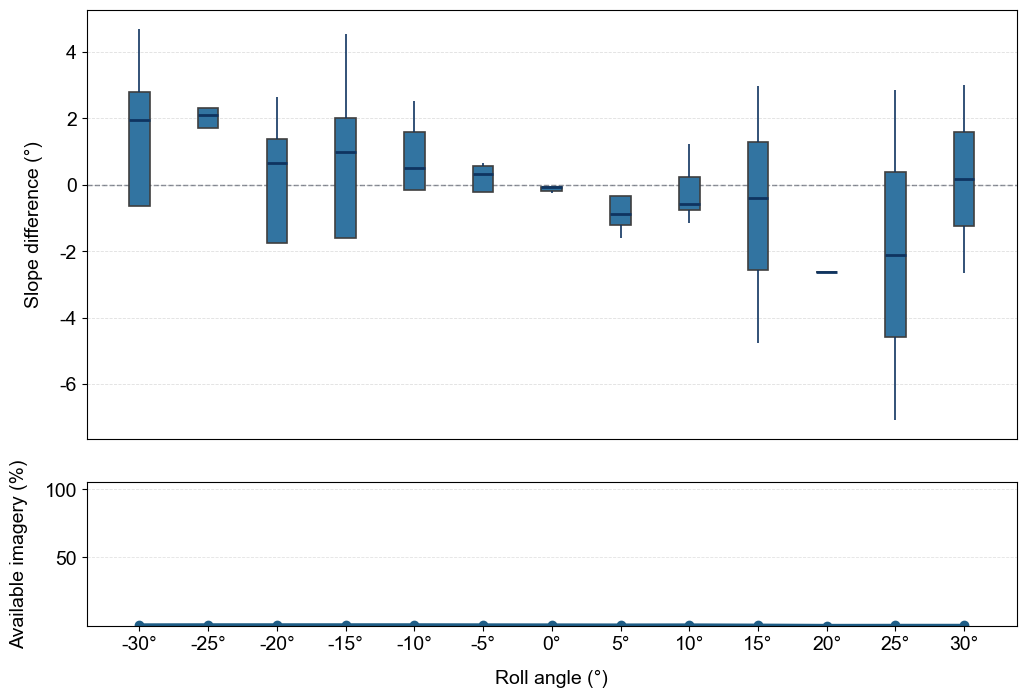

In [32]:
def plot_roll_summary(sample_df, availability_pct, angles, save_path=None):
    import matplotlib.ticker as mticker
    
    angles = list(angles)
    plot_angles = []
    rename_map = {}
    for angle in angles:
        col = f'rolled_{angle}_estimated_slope_diff'
        if col in sample_df.columns:
            plot_angles.append(angle)
            rename_map[col] = f"{angle}°"

    if not plot_angles:
        print("No data to plot.")
        return

    order_labels = [f"{angle}°" for angle in plot_angles]
    plot_df = (
        sample_df[[f'rolled_{angle}_estimated_slope_diff' for angle in plot_angles]]
        .rename(columns=rename_map)
        .melt(var_name='Roll angle (°)', value_name='Slope difference (°)')
    )
    plot_df['Roll angle (°)'] = pd.Categorical(plot_df['Roll angle (°)'], categories=order_labels, ordered=True)

    # Create figure
    fig = plt.figure(constrained_layout=False, figsize=(12, 8))
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.15)
    
    # Boxplot
    highlight_color = sns.color_palette('crest', n_colors=7)[-2]
    ax_box = fig.add_subplot(gs[0])
    sns.boxplot(
        data=plot_df,
        x='Roll angle (°)',
        y='Slope difference (°)',
        ax=ax_box,
        width=0.3,
        fliersize=2.2,
        linewidth=1.2,
        medianprops={'color': '#0F3460', 'linewidth': 2},
        whiskerprops={'color': '#0F3460', 'linewidth': 1.2},
        capprops={'color': '#0F3460', 'linewidth': 1.2},
        showfliers=False,
        showcaps=False
    )
    
    for patch in ax_box.artists:
        patch.set_alpha(0.38)
        patch.set_edgecolor('#0F3460')
        patch.set_facecolor('none')

    ax_box.axhline(0, color='#5B6270', linestyle='--', linewidth=1, alpha=0.8, zorder=0)
    ax_box.set_xlabel('')
    ax_box.set_ylabel('Slope difference (°)', labelpad=12)
    ax_box.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.4)
    ax_box.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
    
    # Remove x-axis labels for boxplot
    ax_box.set_xticklabels([])
    ax_box.tick_params(axis='x', which='both', length=0, labelbottom=False)

    # Availability Line Plot
    positions = np.arange(len(order_labels))
    
    ax_line = fig.add_subplot(gs[1], sharex=ax_box)
    ax_line.plot(positions, availability_pct, color=highlight_color, marker='o', linewidth=2.4, label='Availability')
    ax_line.fill_between(positions, availability_pct, color=highlight_color, alpha=0.15)
    
    ax_line.set_ylabel('Available imagery (%)', labelpad=12)
    ax_line.set_xlabel('Roll angle (°)', labelpad=12)
    ax_line.set_xticks(positions)
    ax_line.set_xticklabels(order_labels)
    ax_line.set_ylim(min(min(availability_pct), 60) * 0.7, max(105, max(availability_pct) * 1.05))
    ax_line.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.35)

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Plot
plot_roll_summary(
    analyzed_df,
    availability,
    ROLL_ANGLES,
    save_path=FIGURE_SAVE_PATH
)